# **Machine Learning Project**

# **Cardiac Arrest Prediction System with Early Prediction**

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import shap

In [2]:
# 1. Generate Dataset

np.random.seed(42)

num_patients = 300      # Number of patients
records_per_patient = 20  # Number of records per patient

patient_ids = []
heart_rate = []
resp_rate = []
body_temp = []
oxygen_sat = []
systolic_bp = []
diastolic_bp = []
age = []
gender = []
weight = []
height = []
derived_hrv = []
derived_pulse_pressure = []
derived_bmi = []
derived_map = []
risk_category = [] # Numerical risk: 0 = Low Risk, 1 = High Risk
timestamp = []

for pid in range(1, num_patients+1):
    base_age = np.random.randint(20, 80)
    base_weight = np.random.randint(50, 100)
    base_height = np.random.uniform(1.5, 2.0)
    gen = np.random.choice(['Male','Female'])

    # 40% patients are High Risk
    high_risk_patient = np.random.rand() < 0.4

    for t in range(records_per_patient):
        # Base vital signs
        hr_base = np.random.normal(75, 10)
        spo2_base = np.random.normal(96, 2)
        sys_base = np.random.normal(120, 15)
        dia_base = np.random.normal(80, 10)

        # Modify vitals for high risk patients
        if high_risk_patient:
            hr = hr_base + np.random.normal(10,5)
            spo2 = spo2_base - np.random.normal(3,1)
            sys = sys_base + np.random.normal(15,5)
        else:
            hr = hr_base + np.random.normal(0,5)
            spo2 = spo2_base + np.random.normal(0,1)
            sys = sys_base + np.random.normal(0,5)

        dia = dia_base + np.random.normal(0,3)

        patient_ids.append(pid)
        heart_rate.append(hr)
        resp_rate.append(np.random.randint(12, 30) + np.random.normal(0,1))
        body_temp.append(np.random.uniform(36.0, 39.0) + np.random.normal(0,0.2))
        oxygen_sat.append(spo2)
        systolic_bp.append(sys)
        diastolic_bp.append(dia)
        age.append(base_age)
        gender.append(gen)
        weight.append(base_weight + np.random.normal(0,2))
        height.append(base_height + np.random.normal(0,0.02))
        derived_hrv.append(np.random.uniform(20, 100))
        derived_pulse_pressure.append(sys - dia)
        derived_bmi.append(base_weight / (base_height**2))
        derived_map.append((sys + 2*dia)/3)
        risk_category.append(1 if high_risk_patient else 0)
        timestamp.append(pd.Timestamp('2025-01-01') + pd.Timedelta(minutes=t))

In [3]:
# Create DataFrame
df = pd.DataFrame({
    "Patient ID": patient_ids,
    "Heart Rate": heart_rate,
    "Respiratory Rate": resp_rate,
    "Body Temperature": body_temp,
    "Oxygen Saturation": oxygen_sat,
    "Systolic Blood Pressure": systolic_bp,
    "Diastolic Blood Pressure": diastolic_bp,
    "Age": age,
    "Gender": gender,
    "Weight (kg)": weight,
    "Height (m)": height,
    "Derived_HRV": derived_hrv,
    "Derived_Pulse_Pressure": derived_pulse_pressure,
    "Derived_BMI": derived_bmi,
    "Derived_MAP": derived_map,
    "Risk_num": risk_category,
    "Timestamp": timestamp
})

# Encode categorical variables
df["Gender_num"] = df["Gender"].map({"Male":1,"Female":0})

print("Number of patients per category:")
print(df.groupby("Risk_num")["Patient ID"].nunique())

Number of patients per category:
Risk_num
0    179
1    121
Name: Patient ID, dtype: int64


In [4]:
df.head()

,Patient ID,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk_num,Timestamp,Gender_num
0,1,70.311094,23.022222,37.114024,96.074286,141.371104,86.277158,58,Female,77.497912,1.588440,69.470881,55.093946,30.786667,104.641807,0,2025-01-01 00:00:00,0
1,1,73.799032,12.398293,36.736570,97.843467,126.881491,82.310815,58,Female,76.932702,1.591607,92.745632,44.570676,30.786667,97.167707,0,2025-01-01 00:01:00,0
2,1,76.584519,19.785532,39.414718,93.755174,126.825287,60.917404,58,Female,78.946386,1.604901,63.175371,65.907883,30.786667,82.886698,0,2025-01-01 00:02:00,0
3,1,75.391063,12.582123,38.364571,95.658522,97.132957,86.389122,58,Female,76.321565,1.585533,89.048274,10.743835,30.786667,89.970400,0,2025-01-01 00:03:00,0
4,1,65.817049,12.326845,38.530518,97.301086,121.507995,76.785851,58,Female,76.132474,1.607402,40.485466,44.722144,30.786667,91.693232,0,2025-01-01 00:04:00,0


In [5]:
# 2. Features and Scaling
features = [
    "Heart Rate", "Respiratory Rate", "Body Temperature", "Oxygen Saturation",
    "Systolic Blood Pressure", "Diastolic Blood Pressure", "Derived_MAP",
    "Derived_HRV", "Derived_Pulse_Pressure", "Derived_BMI", "Age", "Gender_num"
]

X = df[features]
y = df["Risk_num"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# 3. Create LSTM sequences with lookahead
T = 5           # timesteps for LSTM
lookahead = 10  # predict 10 minutes ahead
seq_X, seq_y = [], []

for pid, g in df.groupby("Patient ID"):
    g_feat = scaler.transform(g[features])
    g_label = g["Risk_num"].values

    # ensure we don't go beyond the end of the records
    if len(g_feat) < T + lookahead:
        continue

    for i in range(len(g_feat) - T - lookahead + 1):
        seq_X.append(g_feat[i:i+T])
        seq_y.append(g_label[i+T-1+lookahead])

seq_X = np.array(seq_X)
seq_y = np.array(seq_y)

# Train/test split
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    seq_X, seq_y, test_size=0.2, random_state=42, stratify=seq_y
)

input_dim = X_train_np.shape[2]

In [7]:
# 4. Build and Train LSTM Model
# Handle imbalanced data
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_np),
    y=y_train_np
)
class_weights = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weights)

# Define LSTM model
model_lstm = Sequential([
    Input(shape=(T, input_dim)),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_lstm.compile(optimizer='adam', loss='binary_crossentropy',
                   metrics=['accuracy', tf.keras.metrics.AUC(name='AUC')])

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train model with class weights
history = model_lstm.fit(
    X_train_np, y_train_np,
    epochs=15, batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Class weights: {0: np.float64(0.8381839348079162), 1: np.float64(1.2392426850258176)}
Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - AUC: 0.8576 - accuracy: 0.7602 - loss: 0.5732 - val_AUC: 0.9954 - val_accuracy: 0.9757 - val_loss: 0.2318
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.9958 - accuracy: 0.9774 - loss: 0.1739 - val_AUC: 0.9962 - val_accuracy: 0.9792 - val_loss: 0.0745
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.9956 - accuracy: 0.9718 - loss: 0.0823 - val_AUC: 0.9965 - val_accuracy: 0.9826 - val_loss: 0.0618
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.9984 - accuracy: 0.9838 - loss: 0.0539 - val_AUC: 0.9976 - val_accuracy: 0.9826 - val_loss: 0.0560
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.9986 - accuracy: 0.9878 - loss: 0.0492 - val_AUC: 0.9949 - val_accuracy: 0.9826 - val_loss: 0.0511
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.9985 - accuracy: 0.9826 - loss: 0.0485 - val_AUC: 0.9950 - val_a

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Classification Report:

              precision    recall  f1-score   support

    Low Risk       1.00      0.98      0.99       215
   High Risk       0.97      0.99      0.98       145

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360

Accuracy: 0.9833333333333333
Precision: 0.9664429530201343
Recall: 0.993103448275862
F1-score: 0.9795918367346939
ROC AUC: 0.999037690457097


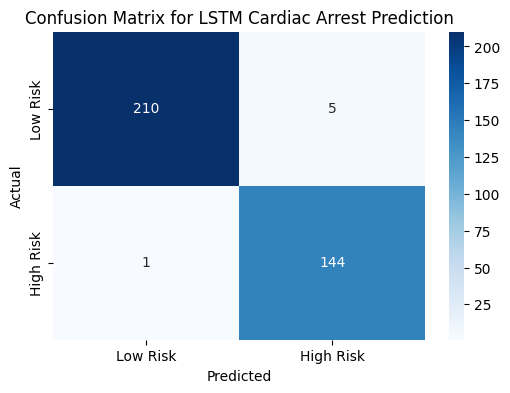

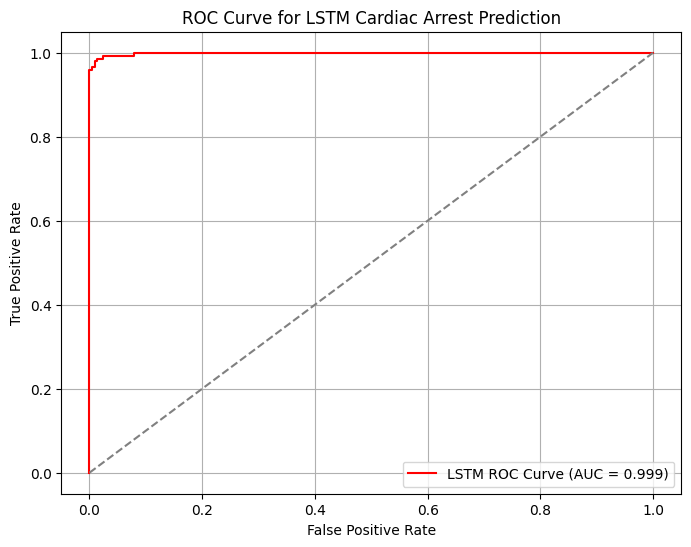

In [8]:
# 5. Evaluate Model
y_prob = model_lstm.predict(X_test_np).ravel()
y_pred = (y_prob>=0.5).astype(int)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test_np, y_pred, target_names=['Low Risk','High Risk']))

print("Accuracy:", accuracy_score(y_test_np, y_pred))
print("Precision:", precision_score(y_test_np, y_pred))
print("Recall:", recall_score(y_test_np, y_pred))
print("F1-score:", f1_score(y_test_np, y_pred))
print("ROC AUC:", roc_auc_score(y_test_np, y_prob))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_np, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk','High Risk'], yticklabels=['Low Risk','High Risk'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for LSTM Cardiac Arrest Prediction')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_np, y_prob)
roc_auc = roc_auc_score(y_test_np, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'LSTM ROC Curve (AUC = {roc_auc:.3f})', color='red')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LSTM Cardiac Arrest Prediction')
plt.legend(loc='lower right')
plt.grid()
plt.show()

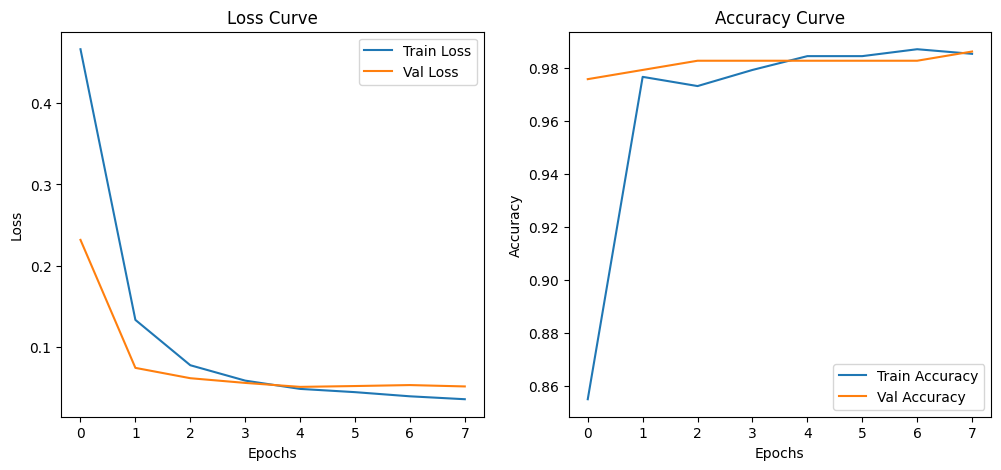

In [9]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [10]:
# 6. Explain Patient Prediction using SHAP
shap.initjs()

def explain_patient(patient_id):
    if patient_id not in df['Patient ID'].unique():
        print("Patient ID not found.")
        return

    patient_data = df[df['Patient ID']==patient_id][features].values
    if len(patient_data) < T:
        print("Not enough records (less than T timesteps).")
        return

    # Prepare LSTM input
    seq_data = patient_data[-T:].reshape(1, T, len(features))
    sample_prob = model_lstm.predict(seq_data, verbose=0)[0][0]
    sample_pred = 'High Risk' if sample_prob >= 0.5 else 'Low Risk'
    actual_risk = 'High Risk' if df[df['Patient ID']==patient_id]['Risk_num'].iloc[-1]==1 else 'Low Risk'

    print(f"\n🧍Patient ID: {patient_id}")
    print(f"✔ Actual Risk: {actual_risk}")
    print(f"✔ Predicted Risk: {sample_pred} {sample_prob:.2f}")

    # Alerts
    thresholds = {"Heart Rate":100, "Oxygen Saturation":92, "Systolic Blood Pressure":160,
                  "Derived_BMI":30, "Derived_MAP":105, "Respiratory Rate":25}
    alerts = [f"⚠️ {feat} abnormal ({seq_data[0,-1,features.index(feat)]:.2f})"
              for feat, val in thresholds.items()
              if (feat in ["Oxygen Saturation"] and seq_data[0,-1,features.index(feat)] < val) or
                 (feat not in ["Oxygen Saturation"] and seq_data[0,-1,features.index(feat)] > val)]
    if alerts:
        print("\n🚨 Alerts:")
        print("\n".join(alerts))

    # SHAP explanation (top 5 features)
    sample_2d = seq_data.reshape(1, T*len(features))
    background = X_train_np[:100].reshape(100, T*len(features))
    explainer = shap.KernelExplainer(lambda x: model_lstm.predict(x.reshape(x.shape[0], T, len(features))).flatten(), background)
    shap_vals = explainer.shap_values(sample_2d)[0][-len(features):]
    top_feats = sorted(zip(features, shap_vals), key=lambda x: abs(x[1]), reverse=True)[:5]

    print("\n🔍 Top 5 Factors Influencing Prediction:")
    for feat, val in top_feats:
        impact = "High Risk" if val>0 else "Low Risk"
        print(f"- {feat}: {val:.2f} ({impact})")

    # Plot probabilities
    plt.bar(['Low Risk','High Risk'], [1-sample_prob, sample_prob], color=['green','red'])
    plt.ylim(0,1)
    plt.ylabel("Probability")
    plt.title(f"Patient Risk Prediction")
    for j, prob in enumerate([1-sample_prob, sample_prob]):
        plt.text(j, prob+0.02, f'{prob:.2f}', ha='center')
    plt.show()

Enter Patient ID (or 0 to exit): 7

🧍Patient ID: 7
✔ Actual Risk: High Risk
✔ Predicted Risk: High Risk 0.81

🚨 Alerts:
⚠️ Heart Rate abnormal (101.57)
⚠️ Respiratory Rate abnormal (26.43)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
6775/6775 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step

🔍 Top 5 Factors Influencing Prediction:
- Oxygen Saturation: -0.43 (Low Risk)
- Heart Rate: 0.20 (High Risk)
- Systolic Blood Pressure: 0.17 (High Risk)
- Derived_Pulse_Pressure: 0.12 (High Risk)
- Respiratory Rate: 0.00 (Low Risk)


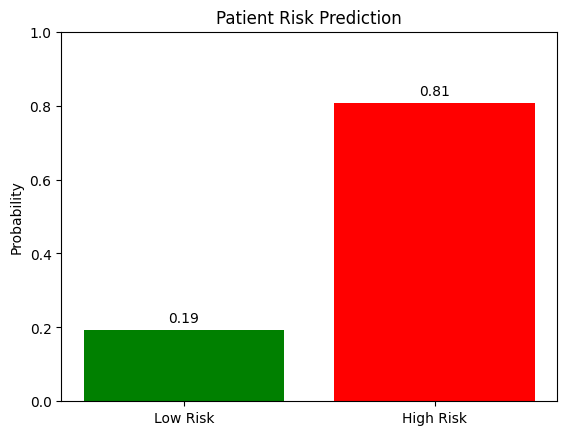

Enter Patient ID (or 0 to exit): 0
Program terminated.


In [11]:
0
# 7. Interactive Query Loop
while True:
    pid_input = input("Enter Patient ID (or 0 to exit): ")
    if not pid_input.isdigit():
        print("Please enter a valid number.")
        continue
    pid_input = int(pid_input)
    if pid_input == 0:
        print("Program terminated.")
        break
    explain_patient(pid_input)